# mistsim vs Raul: epoch, normalisation and conventions

`raul_comparison.ipynb` asks what each **code version** changed. This
notebook holds the code fixed (current mistsim and croissant) and asks
which **comparison choices** explain the residual against Raul
Monsalve's 2026 test simulations. Raul's 2022 code
(`MIST-Experiment/raul_global21cm/astro.py` @ `4c2d125`) shows how his
simulator differs from mistsim. MISTIC analysis queue item **S9**.

| Test | Site | Blockage |
|---|---|---|
| 0 | MARS spot 2 (79.418 N, 90.748 W, 150 m) | 10° at all azimuths |
| 1 | MARS spot 2 | none |
| 2 | North Pole (0 m) | none |

All tests use Haslam (Remazeilles 2014) at nside 128, scaled with
β = −2.55 above T_CMB, and the FEKO beam
`beam_best_fit_meas_39_joint_wide.out` with the dipole along N–S. The
band is 40–125 MHz at 1 MHz, with 241 LSTs at 6-min steps.

**The answer** (rms of mistsim − Raul, K; Test 0 / 1 / 2):

| setup | rms (K) |
|---|---|
| old setup (Raul's LSTs placed on 2022-07-17) | 2.01 / 1.43 / 1.30 |
| + Raul's own time grid (2014-01-01) | 1.36 / 0.28 / 0.40 |
| + mirrored beam, and a half-weight θ = 80° row for Test 0's mask | 0.26 / 0.25 / 0.37 |
| *pixel replica of Raul's code (the floor)* | *0.19 / 0.19 / 0.21* |

1. **The epoch was the main cause.** Raul's LSTs belong to 2014 dates
   (§ 1–2).
2. **Test 0's excess is the mask edge** on the 1° beam grid (§ 2).
3. **Raul's normalisation was not the cause.** The comparison already
   used it (§ 5).
4. **Conventions:** mistsim's beam azimuth runs N → W, Raul's N → E. The
   horizon mask stays on the ground under mistsim's default since
   `bdfabec` (§ 6).

**How the results are made.** This notebook only loads them, so it
needs only numpy and matplotlib. Everything is computed by
`normalization/run.py` in the project environment, with the variants
defined in `normalization/variants.py`:

```bash
uv run python notebooks/sim_comparisons/normalization/run.py   # ~30 min, ~11 GB peak
```

It writes `results_normalization/summary.json` (committed) and the runs
under `results_normalization/cache/` (`.npz`, git-ignored). Raul's
inputs are read in place from `data/2026021{5,20}_for_christian`.
Residuals are always **mistsim − Raul** in K.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, LogLocator

%matplotlib inline

HERE = Path.cwd()
sys.path.insert(0, str(HERE / "normalization"))
import variants as V

SUM = json.loads(V.SUMMARY.read_text())
R = SUM["residual_mistsim_minus_raul"]
z = np.load(V.CACHE / "raul.npz")
freqs = z["freqs"]
TESTS = V.TESTS
raul = {k: z[f"raul{k}"] for k in TESTS}
lsts = {k: z[f"lst{k}"] for k in TESTS}
VAR = {v["key"]: v for v in V.VARIANTS}

runs, fgnd = {}, {}
for v in V.VARIANTS:
    for k in V.tests_of(v):
        f = np.load(V.cache_path(v["key"], k))
        runs[(k, v["key"])], fgnd[(k, v["key"])] = f["tant"], f["fgnd"]
for k in TESTS:
    f = np.load(V.CACHE / f"pix_test{k}.npz")
    runs[(k, "pix")], runs[(k, "pix_mirror")] = f["pix"], f["pix_mirror"]

SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
         "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update({
    "font.size": 10, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2,
    "image.interpolation": "none",
})


def rms(d, axis=None):
    return np.sqrt(np.mean(np.square(d), axis=axis))


def fmt(s):
    return f"{s['mean_K']:.2f} / {s['rms_K']:.2f} / {s['max_abs_K']:.1f}"


p = SUM["provenance"]
print(f"computed with mistsim {p['mistsim_commit']}"
      f"{' (dirty src)' if p['mistsim_src_dirty'] else ''}, croissant "
      f"{p['croissant']} ({p['croissant_commit']}), jax {p['jax']}, "
      f"lmax {p['lmax']}, nside {p['nside']}")

computed with mistsim 34fcc96, croissant v5.3.0.dev4 (a83a986), jax 0.11.1, lmax 100, nside 128


## 1. Raul's inputs

**Time grid.** Raul's 2022 `galactic_to_local_coordinates_24h_LST`
(astro.py:625) works as follows:
- It starts at UTC 2014-01-01 09:29:45 (LST = 0 h at EDGES).
- It steps 359 s and takes `ceil(86164/359) = 241` steps.
- It labels each step with its apparent sidereal time (`utc2lst`:
  IAU2006A, DUT1 = 0) and sorts by LST.

Rebuilding that grid at each test site reproduces the `lst` arrays of
his 2026 files to machine precision. His 2026 code therefore used the
same grid: **the epoch is 2014-01-01.**

**Beam.** `data/feko_beam.npz` is the total gain of Raul's FEKO file,
checked against the `.out` file at three frequencies. The beam is
both two-fold symmetric (φ → φ + 180°) and mirror symmetric (φ → −φ):
to 4e-5 of its peak at 40 MHz and 1.5e-3 at 125 MHz.

In [2]:
g = SUM["raul_time_grid"]
print(f"UTC {g['utc_start']} + i x {g['step_s']} s, {g['n']} steps; "
      f"LST {g['lst']}")
for t, e in g["max_abs_lst_error_h"].items():
    print(f"  {t}: max |LST rebuilt - LST Raul| = {e:.1e} h")
rows = ["| frequency | npz vs .out | asymmetry φ+180° | asymmetry φ→−φ |",
        "|---|---|---|---|"]
for fr, c in SUM["beam_check"].items():
    rows.append(f"| {fr} | {c['max_rel_diff_npz_vs_out']:.1e} | "
                f"{c['asym_phi_plus_180']:.1e} | "
                f"{c['asym_phi_minus_phi']:.1e} |")
display(Markdown("*(of the peak gain)*\n\n" + "\n".join(rows)))

UTC 2014-01-01T09:29:45.000 + i x 359 s, 241 steps; LST apparent, IAU2006A, DUT1 = 0, sorted
  test0: max |LST rebuilt - LST Raul| = 5.5e-14 h
  test1: max |LST rebuilt - LST Raul| = 5.5e-14 h
  test2: max |LST rebuilt - LST Raul| = 5.7e-14 h


*(of the peak gain)*

| frequency | npz vs .out | asymmetry φ+180° | asymmetry φ→−φ |
|---|---|---|---|
| 40MHz | 9.6e-101 | 4.3e-05 | 2.3e-05 |
| 80MHz | 2.4e-101 | 2.8e-04 | 2.0e-04 |
| 125MHz | 1.2e-101 | 1.5e-03 | 1.6e-03 |

## 2. The comparison choices

Each mistsim run changes one choice relative to the run it builds on.
The code is the same for all of them. The **pixel replica** re-implements
Raul's 2022 `convolution` in the pixel domain (`raul_tools.py`):
- astropy galactic → AltAz for every pixel and time;
- a bicubic `RectBivariateSpline` of the beam in (EL, AZ), without
  wrapping in AZ;
- sum(B·T·m) / sum(B·m) over EL ≥ 0, with m = (EL ≥ 10°) for Test 0.

It is the floor this comparison can reach. Residuals are
**mistsim − Raul** in K: mean / rms / max |Δ| over 241 LSTs × 86
frequencies.

In [3]:
rows = ["| run | builds on | what it changes | "
        + " | ".join(TESTS[k] for k in TESTS) + " |",
        "|---|---|---|" + "---|" * len(TESTS)]
for v in V.VARIANTS:
    cells = []
    for k in TESTS:
        key = f"test{k}/{v['key']}"
        cells.append(fmt(R[key]) if key in R else "")
    after = VAR[v["after"]]["label"] if v["after"] else ""
    rows.append(f"| **{v['label']}** | {after} | {v['change']} | "
                + " | ".join(cells) + " |")
rows.append("| *pixel replica* | | Raul's algorithm, independent code | "
            + " | ".join(fmt(R[f"test{k}/pix"]) for k in TESTS) + " |")
display(Markdown("\n".join(rows)))

| run | builds on | what it changes | Test 0: MARS, 10° blockage | Test 1: MARS | Test 2: North Pole |
|---|---|---|---|---|---|
| **old setup** |  | The old raul_comparison.ipynb: Raul's LSTs on 2022-07-17 with mean sidereal time. | 1.07 / 2.01 / 14.9 | 0.75 / 1.43 / 7.3 | 0.72 / 1.30 / 5.1 |
| **+ Raul's time grid** | old setup | Raul's own UTC grid: 2014-01-01 09:29:45 + i x 359 s, apparent sidereal time. | 0.22 / 1.36 / 11.7 | -0.09 / 0.28 / 2.3 | -0.20 / 0.40 / 1.9 |
| **+ mirrored beam** | + Raul's time grid | Beam gain(-phi): Raul maps phi onto azimuth N->E, mistsim at beam_az_rot = 0 runs N->W. | 0.22 / 1.35 / 11.7 | -0.09 / 0.25 / 2.3 | -0.20 / 0.37 / 1.9 |
| **+ half-weight edge row** | + mirrored beam | Test 0's theta = 80 deg row at weight 0.5, so the horizon sits at 80 deg instead of ~80.5 deg. | -0.09 / 0.26 / 2.4 |  |  |
| **edge row blocked** | + mirrored beam | Test 0's theta = 80 deg row blocked (edge ~79.5 deg): brackets the edge from the other side. | -0.41 / 1.42 / 13.2 |  |  |
| **half-weight edge, unmirrored** | + Raul's time grid | The half-weight edge row on mistsim's own (right-handed) beam azimuth: the edge fix without matching Raul's phi = AZ. | -0.09 / 0.28 / 2.4 |  |  |
| **lmax 179** | + half-weight edge row | lmax 100 -> 179. | -0.09 / 0.26 / 2.5 | -0.09 / 0.25 / 2.3 | -0.20 / 0.37 / 1.9 |
| **sky SHT niter 3** | + half-weight edge row | HEALPix sky transform iterated 3 times (default 0). | -0.09 / 0.26 / 2.4 | -0.09 / 0.26 / 2.3 | -0.20 / 0.38 / 1.9 |
| **full-sphere norm** | + Raul's time grid | Tgnd = 0 and no correction: divide by the whole beam, blocked beam sees 0 K (the pipeline's simulate_waterfall). | -29.79 / 48.83 / 214.2 |  |  |
| **Tgnd = 300 K** | + Raul's time grid | Simulator.sim with mistsim's default Tgnd = 300 K. | -25.85 / 44.15 / 209.0 |  |  |
| *pixel replica* | | Raul's algorithm, independent code | -0.00 / 0.19 / 1.9 | -0.01 / 0.19 / 1.9 | -0.12 / 0.21 / 1.0 |

The main path from the old setup to the best one, with the
pixel replica as the dotted floor:

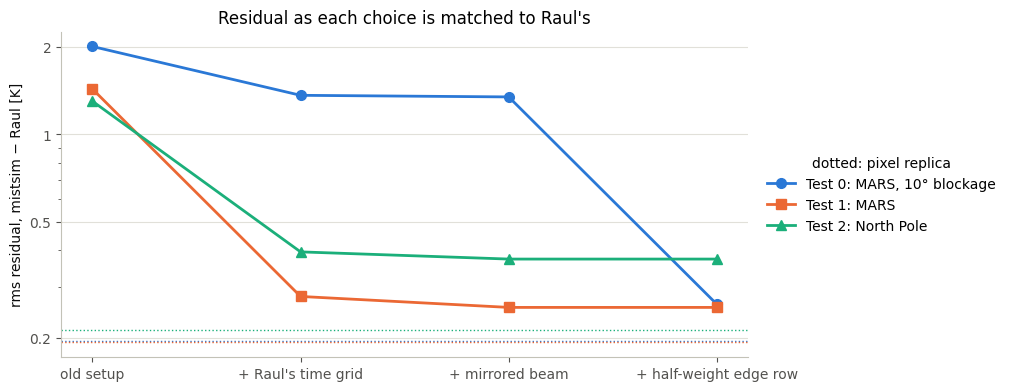

In [4]:
PATH = ["base", "epoch", "mirror", "edge"]
fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
marker = {0: "o", 1: "s", 2: "^"}
for k in TESTS:
    y = [R[f"test{k}/{V.run_key(VAR[n], k)}"]["rms_K"] for n in PATH]
    ax.plot(range(len(PATH)), y, marker=marker[k], ms=7, color=SLOTS[k],
            label=TESTS[k])
    ax.axhline(R[f"test{k}/pix"]["rms_K"], color=SLOTS[k], lw=1, ls=":")
ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ""))
ax.set_xticks(range(len(PATH)), [VAR[n]["label"] for n in PATH])
ax.set_ylabel("rms residual, mistsim − Raul [K]")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(title="dotted: pixel replica", loc="center left",
          bbox_to_anchor=(1.01, 0.5))
ax.set_title("Residual as each choice is matched to Raul's")
plt.show()

**The epoch.** `base` and `epoch` differ only in the time grid.
That alone takes the rms from 1.43 to 0.28 K (Test 1) and from 1.30 to
0.40 K (Test 2).

The residual it removes is not a pure LST shift:
- **The best-fit lag is −21 s** for Tests 1 and 2: the least-squares
  coefficient of the residual on dT/dLST, the `lag_fit_s` in
  `summary.json`. That is close to the 26 s of general precession in
  right ascension over 8.5 years.
- **Subtracting the lag barely helps:** it lowers the Test 1 rms only
  from 1.43 to 1.34 K. The rest is the change of the celestial frame
  itself between the two epochs, which no time shift absorbs:
  precession moves the pole by ~2.8′ over 8.5 years, plus nutation.

**Test 0's excess is the mask edge.** With `θ ≤ 80°`, mistsim keeps the
80° row, which stands for 79.5°–80.5° on the 1° grid. Blocking that row
instead flips the sign of the mean. Giving it half weight brings Test 0
to Test 1's level. The pixel replica puts the edge at exactly 10° of
elevation.

**Small or nil:** the beam mirror (this dipole is nearly mirror
symmetric), lmax 179 and a 3-iteration HEALPix sky transform.

## 3. The data

Raul's antenna temperature, then Raul's and mistsim's spectra at
four LSTs (mistsim: the `epoch` run). At this scale the two cannot be
told apart, so the residuals follow below. At the North Pole, the
spectra at LST 0 and 12 h (and at 6 and 18 h) coincide, as they must
for a two-fold symmetric dipole turning about the pole.

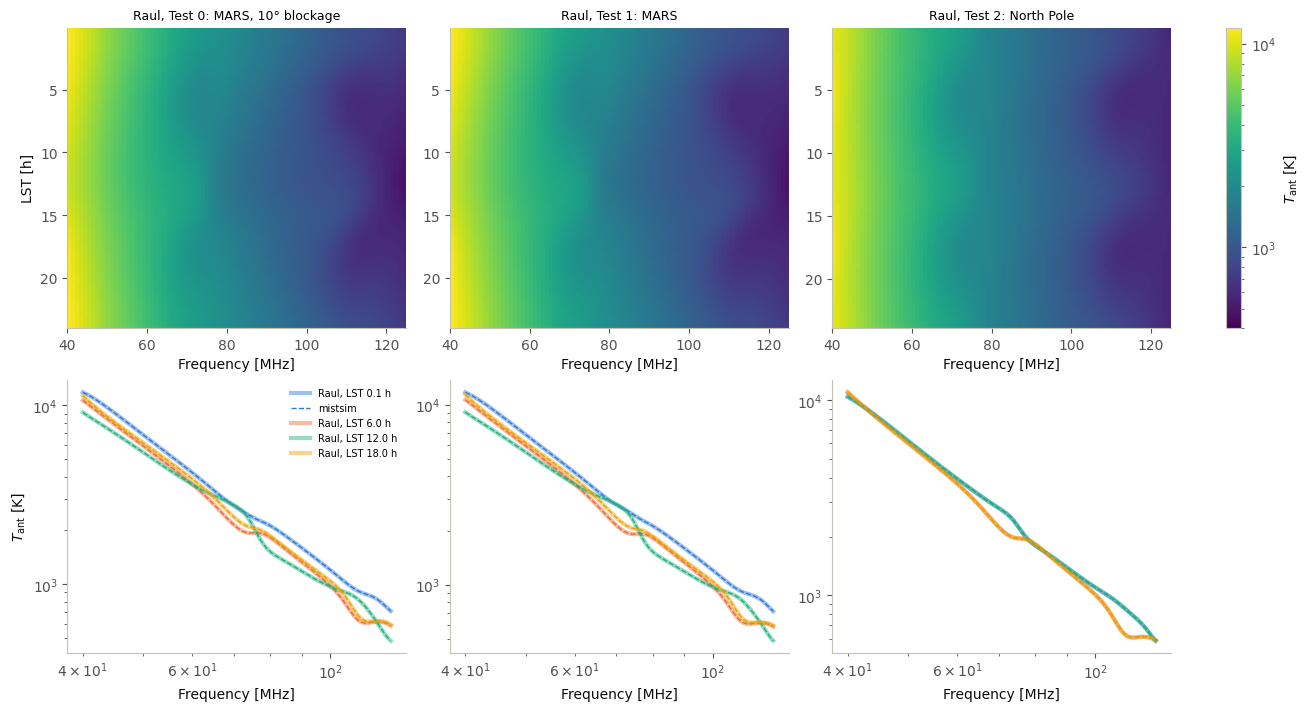

In [5]:
fig, axs = plt.subplots(
    2, 3, figsize=(13, 7), constrained_layout=True,
    gridspec_kw={"height_ratios": [1.1, 1]},
)
show_lsts = [0.0, 6.0, 12.0, 18.0]
for j, k in enumerate(TESTS):
    ext = [freqs[0], freqs[-1], lsts[k][-1], lsts[k][0]]
    im = axs[0, j].imshow(
        raul[k], extent=ext, aspect="auto", cmap="viridis",
        norm=plt.matplotlib.colors.LogNorm(400, 12000),
    )
    axs[0, j].set_title(f"Raul, {TESTS[k]}", fontsize=9)
    axs[0, j].set_xlabel("Frequency [MHz]")
    for c, L in zip(SLOTS, show_lsts):
        i = int(np.argmin(np.abs(lsts[k] - L)))
        axs[1, j].loglog(freqs, raul[k][i], color=c, lw=3, alpha=0.45,
                         label=f"Raul, LST {lsts[k][i]:.1f} h")
        axs[1, j].loglog(freqs, runs[(k, "epoch")][i], color=c, ls="--",
                         lw=1, label="mistsim" if L == 0 else None)
    axs[1, j].set_xlabel("Frequency [MHz]")
axs[0, 0].set_ylabel("LST [h]")
axs[1, 0].set_ylabel(r"$T_{\rm ant}$ [K]")
axs[1, 0].legend(fontsize=7)
fig.colorbar(im, ax=axs[0, :], label=r"$T_{\rm ant}$ [K]")
plt.show()

## 4. Residuals

Waterfalls along the main path, on one colour scale per test, and
then their structure in frequency and time.

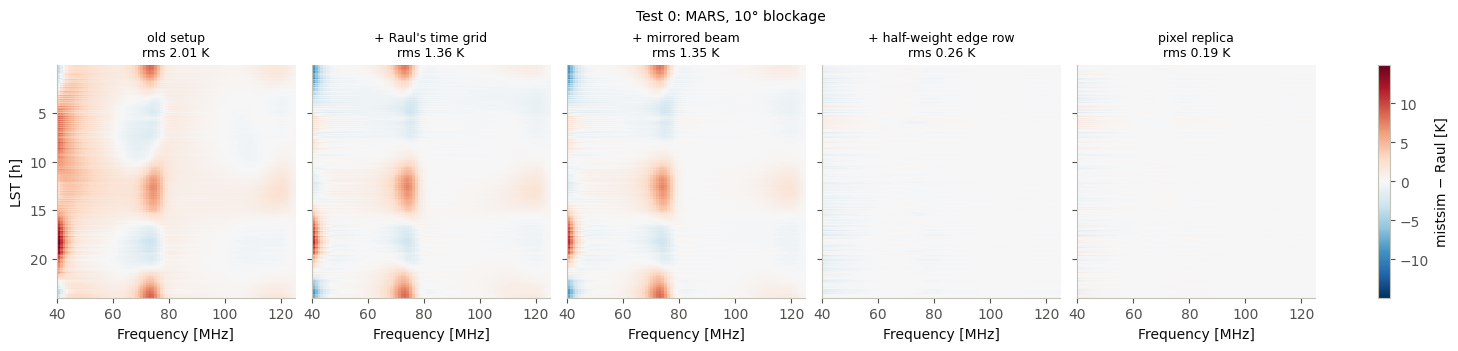

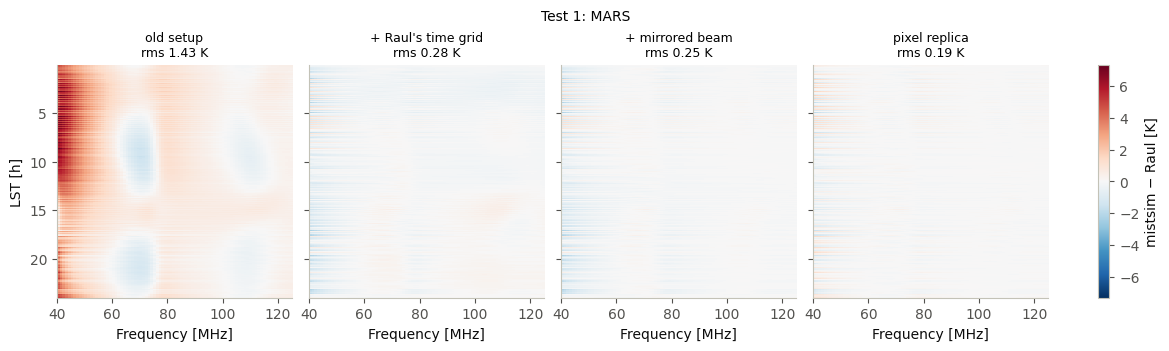

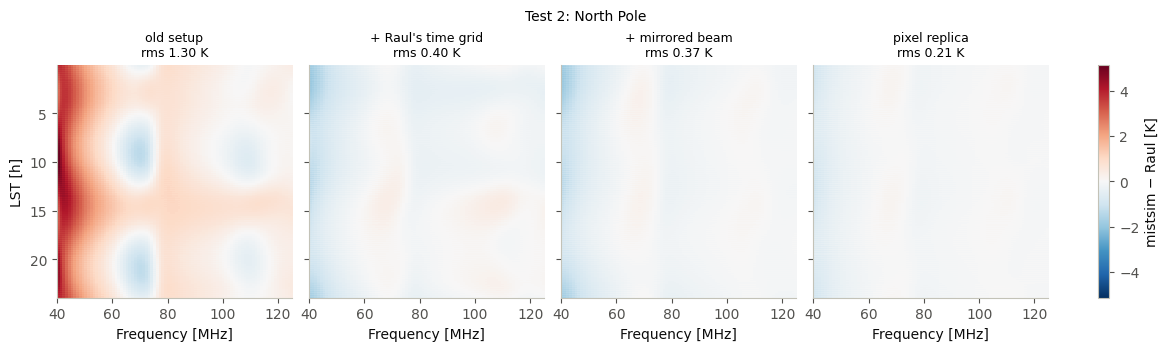

In [6]:
for k in TESTS:
    names = [V.run_key(VAR[n], k) for n in PATH] + ["pix"]
    labels = [VAR[n]["label"] for n in PATH] + ["pixel replica"]
    keep = [i for i in range(len(names))
            if i == 0 or names[i] != names[i - 1]]
    names = [names[i] for i in keep]
    labels = [labels[i] for i in keep]
    ds = [runs[(k, nm)] - raul[k] for nm in names]
    lim = max(float(np.max(np.abs(d))) for d in ds)
    fig, axs = plt.subplots(1, len(ds), figsize=(2.9 * len(ds), 3.4),
                            sharey=True, constrained_layout=True)
    ext = [freqs[0], freqs[-1], lsts[k][-1], lsts[k][0]]
    for ax, lab, d in zip(axs, labels, ds):
        im = ax.imshow(d, extent=ext, aspect="auto", cmap="RdBu_r",
                       vmin=-lim, vmax=lim)
        ax.set_title(f"{lab}\nrms {rms(d):.2f} K", fontsize=9)
        ax.set_xlabel("Frequency [MHz]")
    axs[0].set_ylabel("LST [h]")
    fig.colorbar(im, ax=axs, label="mistsim − Raul [K]")
    fig.suptitle(TESTS[k], fontsize=10)
    plt.show()

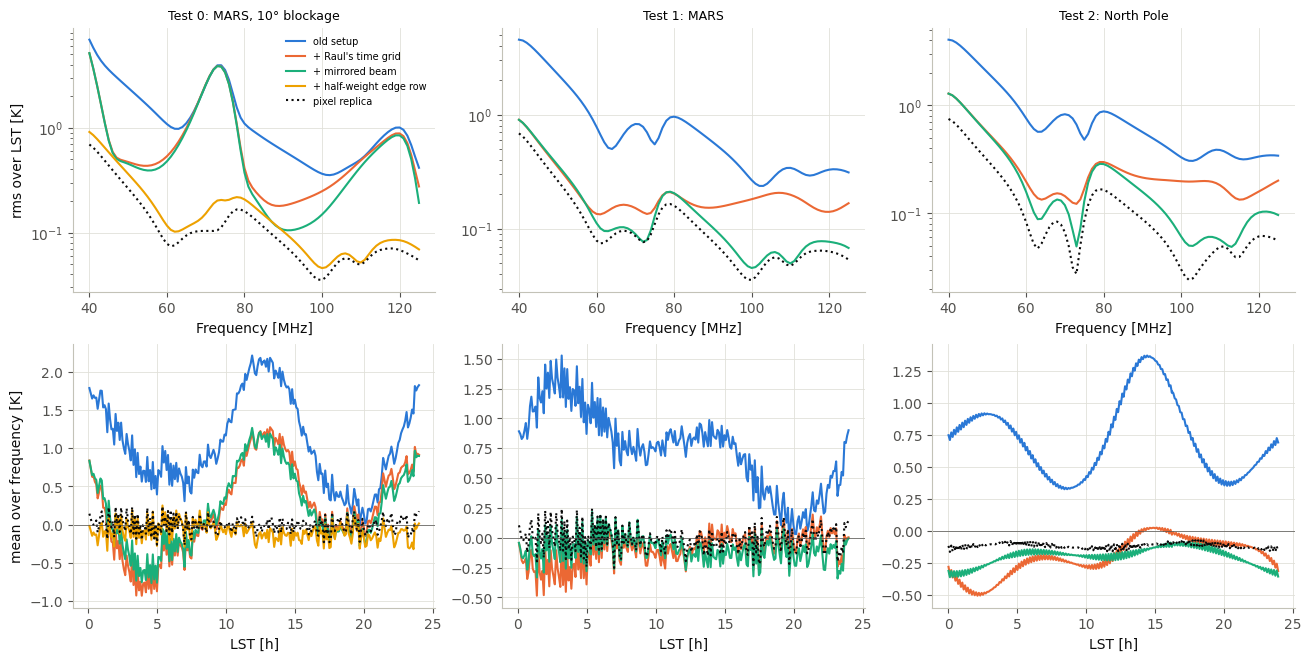

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(13, 6.5), constrained_layout=True)
curves = [(n, VAR[n]["label"], SLOTS[i]) for i, n in enumerate(PATH)]
curves.append(("pix", "pixel replica", INK))
for j, k in enumerate(TESTS):
    for n, lab, c in curves:
        nm = n if n == "pix" else V.run_key(VAR[n], k)
        if n == "edge" and k != 0:
            continue
        d = runs[(k, nm)] - raul[k]
        ls = ":" if n == "pix" else "-"
        axs[0, j].plot(freqs, rms(d, axis=0), color=c, ls=ls, lw=1.5,
                       label=lab)
        axs[1, j].plot(lsts[k], d.mean(axis=1), color=c, ls=ls, lw=1.5,
                       label=lab)
    axs[0, j].set_yscale("log")
    axs[0, j].set_title(TESTS[k], fontsize=9)
    axs[0, j].set_xlabel("Frequency [MHz]")
    axs[1, j].set_xlabel("LST [h]")
    axs[1, j].axhline(0, color=MUTED, lw=0.5)
    for ax in axs[:, j]:
        ax.grid(color=GRID, lw=0.6)
axs[0, 0].set_ylabel("rms over LST [K]")
axs[1, 0].set_ylabel("mean over frequency [K]")
axs[0, 0].legend(fontsize=7)
plt.show()

## 5. Normalisation

**What mistsim divides by** (croissant v5.3.0.dev4 @ `a83a986`,
`site-packages/croissant/`):

- **`Beam.compute_alm`** (beam.py:216–231) transforms
  `data * horizon_in_beam_frame`. The blocked and below-horizon beam is
  zeroed before the harmonic transform.
- **`Simulator.sim`** (simulator.py:434–506) divides the convolution by
  `beam.compute_norm()` (beam.py:183–195). That is the integral of the
  **whole** beam over the sphere, `_compute_norm(use_horizon=False)`
  (beam.py:147–181). It then adds `compute_fgnd() * Tgnd`
  (simulator.py:370–391), with `fgnd = 1 − ∫B·horizon / ∫B`
  (beam.py:198–214). mistsim's `Simulator` defaults to `Tgnd = 300`
  (sim.py:20).
- **`croissant.simulator.correct_ground_loss(vis, fgnd, Tgnd)`**
  (simulator.py:135–163) returns `(vis − fgnd·Tgnd) / (1 − fgnd)`. With
  the same `Tgnd` as the simulation, this equals dividing the convolution
  by the **above-horizon** beam integral `∫B·horizon`. That is Raul's
  sum(B·T·m) / sum(B·m).
- **The comparison already used Raul's normalisation.** Both notebooks
  run `Tgnd = 0`, then `correct_ground_loss(tant, fgnd, 0)`.
- **The pipeline does not.** Its `simulate_waterfall` (pipeline.py:1705)
  and the map-making operators normalise with
  `mapmaking.normalize_beam_alm(..., ground_loss=True)` (mapmaking.py:22),
  the `observation.ground_loss` default. That is the full-sphere integral
  with no ground term, so the blocked beam sees 0 K. `ground_loss: false`
  selects the above-horizon integral.

For Tests 1 and 2 the beam is zero below θ = 90°: FEKO gives gain
1e-100 at the horizon, and the file stops there. So `fgnd = 0` and all
normalisations coincide. Only Test 0 separates them.

In [8]:
a = SUM["normalisation_algebra"]
print("algebra checks (max |difference|, K):")
print(f"  full_sphere = above x (1 - fgnd):              "
      f"{a['full_sphere_eq_above_x_1_minus_fgnd_K']:.1e}")
print(f"  default = above x (1 - fgnd) + 300 fgnd:      "
      f"{a['default_eq_above_x_1_minus_fgnd_plus_300fgnd_K']:.1e}")
f = fgnd[(0, "epoch")]
print(f"Test 0 fgnd: 40 MHz {f[0]:.4f}, 80 MHz {f[40]:.4f}, "
      f"125 MHz {f[-1]:.4f}")
rows = ["| Test 0 normalisation | mean / rms / max \\|Δ\\| (K) |",
        "|---|---|"]
NORMS = {"epoch": "above-horizon (Raul's)",
         "full_sphere": "full sphere, blocked beam at 0 K",
         "default": "full sphere + Tgnd = 300 K (mistsim default)"}
for nm, lab in NORMS.items():
    rows.append(f"| {lab} | {fmt(R[f'test0/{nm}'])} |")
display(Markdown("\n".join(rows)))

algebra checks (max |difference|, K):
  full_sphere = above x (1 - fgnd):              1.8e-12
  default = above x (1 - fgnd) + 300 fgnd:      1.8e-12
Test 0 fgnd: 40 MHz 0.0174, 80 MHz 0.0091, 125 MHz 0.0105


| Test 0 normalisation | mean / rms / max \|Δ\| (K) |
|---|---|
| above-horizon (Raul's) | 0.22 / 1.36 / 11.7 |
| full sphere, blocked beam at 0 K | -29.79 / 48.83 / 214.2 |
| full sphere + Tgnd = 300 K (mistsim default) | -25.85 / 44.15 / 209.0 |

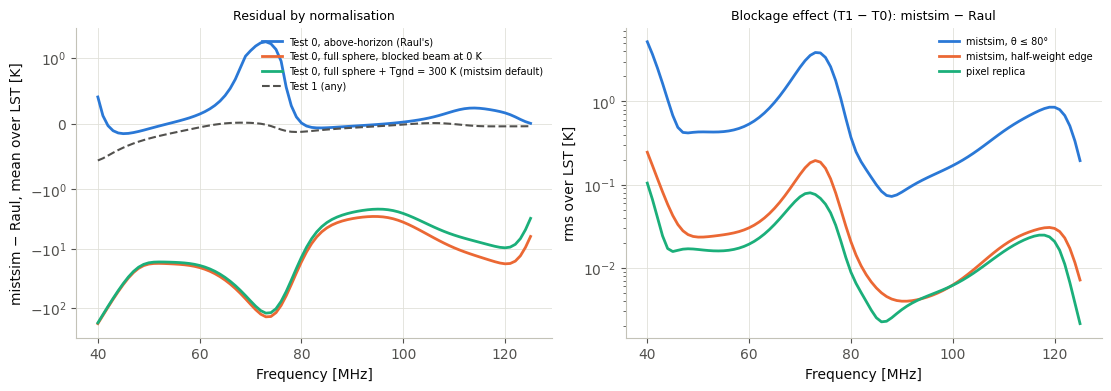

blockage effect itself: rms 11.7 K
  epoch  error: rms 1.355 K, max 11.80 K
  edge   error: rms 0.066 K, max 0.89 K
  pix    error: rms 0.030 K, max 0.32 K
Test 0 fgnd, θ ≤ 80° (edge ~80.5°) : 40MHz 0.0174, 80MHz 0.0091, 125MHz 0.0105
Test 0 fgnd, θ = 80° at weight 0.5 : 40MHz 0.0197, 80MHz 0.0105, 125MHz 0.0118
Test 0 fgnd, θ < 80° (edge ~79.5°) : 40MHz 0.0221, 80MHz 0.0119, 125MHz 0.0130


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for (nm, lab), c in zip(NORMS.items(), SLOTS):
    axs[0].plot(freqs, (runs[(0, nm)] - raul[0]).mean(axis=0), color=c,
                label=f"Test 0, {lab}")
axs[0].plot(freqs, (runs[(1, "epoch")] - raul[1]).mean(axis=0),
            color=MUTED, ls="--", lw=1.5, label="Test 1 (any)")
axs[0].set_yscale("symlog", linthresh=1)
axs[0].set_xlabel("Frequency [MHz]")
axs[0].set_ylabel("mistsim − Raul, mean over LST [K]")
axs[0].legend(fontsize=7)
axs[0].set_title("Residual by normalisation", fontsize=9)
eff_r = raul[1] - raul[0]
for (n0, n1, lab), c in zip(
    [("epoch", "epoch", "mistsim, θ ≤ 80°"),
     ("edge", "mirror", "mistsim, half-weight edge"),
     ("pix", "pix", "pixel replica")], SLOTS):
    eff = runs[(1, n1)] - runs[(0, n0)]
    axs[1].plot(freqs, rms(eff - eff_r, axis=0), color=c, label=lab)
axs[1].set_yscale("log")
axs[1].set_xlabel("Frequency [MHz]")
axs[1].set_ylabel("rms over LST [K]")
axs[1].set_title("Blockage effect (T1 − T0): mistsim − Raul", fontsize=9)
axs[1].legend(fontsize=7)
for ax in axs:
    ax.grid(color=GRID, lw=0.6)
plt.show()
b = SUM["blockage_effect_residual"]
print(f"blockage effect itself: rms {b['effect_rms_K']:.1f} K")
for nm in ("epoch", "edge", "pix"):
    print(f"  {nm:6s} error: rms {b[nm]['rms_K']:.3f} K, "
          f"max {b[nm]['max_abs_K']:.2f} K")
m = SUM["fgnd_test0_by_mask"]
for nm, lab in (("mirror", "θ ≤ 80° (edge ~80.5°)"),
                ("edge", "θ = 80° at weight 0.5"),
                ("edge_lt80", "θ < 80° (edge ~79.5°)")):
    print(f"Test 0 fgnd, {lab:22s}: " + ", ".join(
        f"{fr} {v:.4f}" for fr, v in m[nm].items()))

## 6. Conventions: beam azimuth and the horizon mask

The test uses a synthetic, strongly asymmetric beam
(`raul_tools.synthetic_beam`: cos²θ · (1 + 0.8 sin θ cos(φ − 30°))) and a
one-sided mask (`synthetic_mask`: blocked for θ > 60° at beam-frame
0 ≤ φ < 90°), at 60 MHz, Test 1's site, every 8th of Raul's times.

mistsim at `beam_az_rot` 0° and 40° is compared against the pixel-domain
sum under four hypotheses:
- **the beam's azimuth:** φ_b = AZ − rot (Raul's φ = AZ) or
  φ_b = −(AZ − rot) (mirrored);
- **the mask:** it either rotates with the beam or stays fixed on the
  ground.

It is run with the mask in both of mistsim's horizon frames. The table
gives mean |Δ| in K; the hypothesis that holds is near zero.

**What changed since this notebook was first run:** mistsim `bdfabec`
made `horizon_frame="topocentric"` the default, so a mask now stays
fixed on the ground. Under croissant dev3 the only behaviour was
`"beam"`, where the mask rotated with `beam_az_rot`.

In [10]:
c = SUM["convention_test"]
rows = ["| horizon frame | `beam_az_rot` | φ_b = AZ − rot, mask rotates "
        "| φ_b = AZ − rot, mask fixed | φ_b = −(AZ − rot), mask rotates "
        "| φ_b = −(AZ − rot), mask fixed |",
        "|---|---|---|---|---|---|"]
for frame in ("beam", "topocentric"):
    for rot in ("rot0", "rot40"):
        cells = []
        for mir in (0, 1):
            for mrot in (1, 0):
                v = c[f"{frame}/{rot}/mir{mir}/mrot{mrot}"]["mean_abs_K"]
                cells.append(f"**{v:.1f}**" if v < 5 else f"{v:.1f}")
        rows.append(f"| `{frame}` | {rot[3:]}° | " + " | ".join(cells)
                    + " |")
display(Markdown("\n".join(rows)
                 + f"\n\n(mean T_ant {c['mean_tant_K']:.0f} K)"))

| horizon frame | `beam_az_rot` | φ_b = AZ − rot, mask rotates | φ_b = AZ − rot, mask fixed | φ_b = −(AZ − rot), mask rotates | φ_b = −(AZ − rot), mask fixed |
|---|---|---|---|---|---|
| `beam` | 0° | 236.1 | 236.1 | **2.2** | **2.2** |
| `beam` | 40° | 244.0 | 259.9 | **3.1** | 36.9 |
| `topocentric` | 0° | 236.1 | 236.1 | **2.2** | **2.2** |
| `topocentric` | 40° | 248.1 | 269.0 | 39.1 | **2.1** |

(mean T_ant 3854 K)

## 7. What is left, and what follows

In [11]:
rows = ["| mean / rms / max \\|Δ\\| (K) | "
        + " | ".join(TESTS[k] for k in TESTS) + " |",
        "|---|" + "---|" * len(TESTS)]
sp = SUM["residual_split"]
for part, lab in (("mistsim_minus_replica", "mistsim (best) − pixel replica"),
                  ("replica_minus_raul", "pixel replica − Raul")):
    rows.append(f"| {lab} | "
                + " | ".join(fmt(sp[f"test{k}"][part]) for k in TESTS)
                + " |")
display(Markdown("\n".join(rows)))

| mean / rms / max \|Δ\| (K) | Test 0: MARS, 10° blockage | Test 1: MARS | Test 2: North Pole |
|---|---|---|---|
| mistsim (best) − pixel replica | -0.09 / 0.17 / 1.8 | -0.08 / 0.16 / 0.8 | -0.08 / 0.17 / 1.0 |
| pixel replica − Raul | -0.00 / 0.19 / 1.9 | -0.01 / 0.19 / 1.9 | -0.12 / 0.21 / 1.0 |

The best mistsim setup (`edge` for Test 0, `mirror` for Tests 1 and
2) leaves 0.26 / 0.25 / 0.37 K rms, about 2–4e-5 of T_ant, with a
maximum of 2.4 K at 40 MHz. The table above splits it in two:

- **mistsim − replica** (mean about −0.08 K on every test) is the
  harmonic-space simulator against the pixel-domain one: the
  band-limit, the beam interpolation and the sky transform.
- **replica − Raul** is frequency-structured and largest at 40 MHz. It
  is in Raul's 2026 code and not in his 2022 code. One candidate is the
  FEKO file's printed precision (4-decimal dB, 4-digit fields).

**What follows:**
1. **Horizon edge bias.** A boolean `θ ≤ θ_h` mask on a 1° grid puts the
   horizon about half a row low.
   - mistsim's pipeline now builds fractional edge weights
     (`croissant.horizon_weights`, mistsim #17).
   - croissant#161 asks for `Beam` to accept a horizon angle, so hand-built
     masks stop carrying the bias.
2. **Comparisons with ground-loss-corrected references** (Raul's sims, or
   data corrected for ground loss) need the above-horizon norm:
   `correct_ground_loss`, or `ground_loss: false` in the pipeline.
3. **Terrain horizons** given in compass azimuth go on mistsim's ground
   grid (φ = 0 North, φ = 90° West) under the default
   `horizon_frame="topocentric"`, and stay there whatever `beam_az_rot` is.
4. **Raul's sims are on 2014 dates.** Simulate them on his UTC grid
   (`raul_tools.raul_times`), not from LST alone.
5. **For Raul:** does his 2026 code still map φ = AZ, and how does it read
   the FEKO gain (the dB column or the fields)? The answers would settle
   the last 0.2 K.
